<a href="https://colab.research.google.com/github/LatikaaTejus/Marketing-analysis/blob/main/Strategic_Market_Segmentation_of_Global_Grain_Importers_via_Unsupervised_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Portfolio Project: Global Wheat Export Segmentation
# Optimizing Supply Chain and Market Strategy through Unsupervised Learning


# 1. Business Problem & Context
#  Client: New DG Food Agro (Multinational grain exporter from India with a 130-year history).
#  Core Product: Wheat (Primary export since the 1980s to countries like the USA, Afghanistan, and Australia).
#  The Challenge:Year-over-year export volumes (in tons) are highly volatile due to external factors (floods, population shifts, economic growth). The business cannot identify clear patterns across 18 years of data.
#  The Goal: Segment destination countries into distinct performance tiers to optimize supply chain planning and identify low-performing growth markets.



# 2. Technical Objective
#To build a scalable, repeatable pipeline that reduces the dimensionality of 18 years of historical data using **Principal Component Analysis (PCA)**, and then groups countries using **Unsupervised Clustering (K-Means / Hierarchical)**.


### 3. Data Loading & Exploratory Data Analysis (EDA)
#In this section, we will load the data, inspect its shape, handle missing values, and check data types.*


In [ ]:
# Environment Setup & Data Ingestion
# Import the necessary scientific computing and data manipulation libraries (`pandas`, `numpy`)
# load the raw CSV dataset, and take a preliminary look at its shape and schema.

In [ ]:
import numpy as np            #importing libraries
import pandas as pd
df = pd.read_csv('/Project_Data_1.csv')        #our datatset
df.head()

,Sales of Wheat in tons,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007
0,Afghanistan,436,429,422,415,407,397,397,387,374,373,346,326,304,308,283,267,251,238
1,Albania,42,40,41,42,42,43,42,44,43,42,40,34,32,32,29,29,26,22
2,Algeria,45,44,44,43,43,42,43,44,45,46,48,49,50,51,52,53,55,56
3,American Samoa,42,14,4,18,17,22,0,25,12,8,8,6,5,6,9,11,9,5
4,Andorra,39,37,35,33,32,30,28,23,24,22,20,20,21,18,19,18,17,19


In [ ]:
#Check for missing values and data types
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 207 entries, 0 to 206
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Sales of Wheat in tons  207 non-null    object
 1   1990                    207 non-null    object
 2   1991                    207 non-null    object
 3   1992                    207 non-null    object
 4   1993                    207 non-null    object
 5   1994                    207 non-null    object
 6   1995                    207 non-null    object
 7   1996                    207 non-null    int64 
 8   1997                    207 non-null    int64 
 9   1998                    207 non-null    int64 
 10  1999                    207 non-null    int64 
 11  2000                    207 non-null    int64 
 12  2001                    207 non-null    int64 
 13  2002                    207 non-null    int64 
 14  2003                    207 non-null    int64 
 15  2004  

In [ ]:
# 3.3 Type Casting & Treating Corrupted Text Strings
#During schema evaluation, several historical year columns (`1990-1995`, `2004-2007`) were identified as `object` data types
#rather than numerical values. This indicates the presence of non-numeric characters (like string formatters or commas).
#We must strip these anomalies and cast all analytical variables strictly to floats or integers to prevent execution errors during dimensionality reduction.

In [ ]:
# First, rename our column as planned
df.rename(columns={'Sales of Wheat in tons': 'Country'}, inplace=True)
print (df.Country)


0             Afghanistan
1                 Albania
2                 Algeria
3          American Samoa
4                 Andorra
              ...        
202      Wallis et Futuna
203    West Bank and Gaza
204                 Yemen
205                Zambia
206              Zimbabwe
Name: Country, Length: 207, dtype: object


In [ ]:
# Identify all the year columns
year_columns = [col for col in df.columns if col != 'Country']

# Clean and convert each year column to numeric
for col in year_columns:
    # Remove commas or empty whitespace strings if any exist, then force conversion
    # errors='coerce' will turn any unparseable string into NaN so we can catch it
    df[col] = df[col].astype(str).str.replace(',', '', regex=True).str.strip()
    df[col] = pd.to_numeric(df[col], errors='coerce')


In [ ]:
# Check if forcing numeric conversion created any missing values (NaNs)
print("Missing values after numeric conversion:")
print(df.isnull().sum()[df.isnull().sum() > 0])

# Review the new data types
df.info()

Missing values after numeric conversion:
Series([], dtype: int64)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 207 entries, 0 to 206
Data columns (total 19 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Country  207 non-null    object
 1   1990     207 non-null    int64 
 2   1991     207 non-null    int64 
 3   1992     207 non-null    int64 
 4   1993     207 non-null    int64 
 5   1994     207 non-null    int64 
 6   1995     207 non-null    int64 
 7   1996     207 non-null    int64 
 8   1997     207 non-null    int64 
 9   1998     207 non-null    int64 
 10  1999     207 non-null    int64 
 11  2000     207 non-null    int64 
 12  2001     207 non-null    int64 
 13  2002     207 non-null    int64 
 14  2003     207 non-null    int64 
 15  2004     207 non-null    int64 
 16  2005     207 non-null    int64 
 17  2006     207 non-null    int64 
 18  2007     207 non-null    int64 
dtypes: int64(18), object(1)
memory usage: 30.9+ KB


In [ ]:
# Exploratory Data Analysis (EDA)
# Display summary statistics for all numerical columns
summary_stats = df.describe()
summary_stats

,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007
count,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000
mean,196.966184,196.468599,192.811594,191.173913,188.724638,187.942029,178.898551,180.975845,178.120773,180.473430,177.521739,177.797101,179.516908,176.405797,173.922705,171.183575,169.019324,167.256039
std,232.385067,229.329664,224.805522,220.093799,216.750218,212.477587,193.786752,192.272421,188.843079,195.062942,199.438504,205.102644,205.321624,210.272545,210.486938,211.218437,211.057714,212.246576
min,0.000000,3.000000,3.000000,3.000000,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,42.000000,40.000000,37.500000,37.000000,34.000000,32.500000,31.500000,29.500000,29.000000,28.000000,21.500000,22.500000,24.500000,20.500000,21.000000,19.500000,18.000000,19.000000
50%,96.000000,93.000000,91.000000,88.000000,89.000000,92.000000,88.000000,93.000000,90.000000,90.000000,85.000000,80.000000,79.000000,71.000000,71.000000,66.000000,65.000000,65.000000
75%,290.000000,315.500000,320.000000,316.500000,314.000000,310.500000,306.500000,320.500000,323.000000,345.500000,319.500000,309.000000,306.000000,297.500000,287.500000,282.500000,277.500000,278.000000
max,1485.000000,1477.000000,1463.000000,1442.000000,1414.000000,1381.000000,910.000000,853.000000,777.000000,770.000000,761.000000,832.000000,932.000000,960.000000,1034.000000,1046.000000,1093.000000,1104.000000


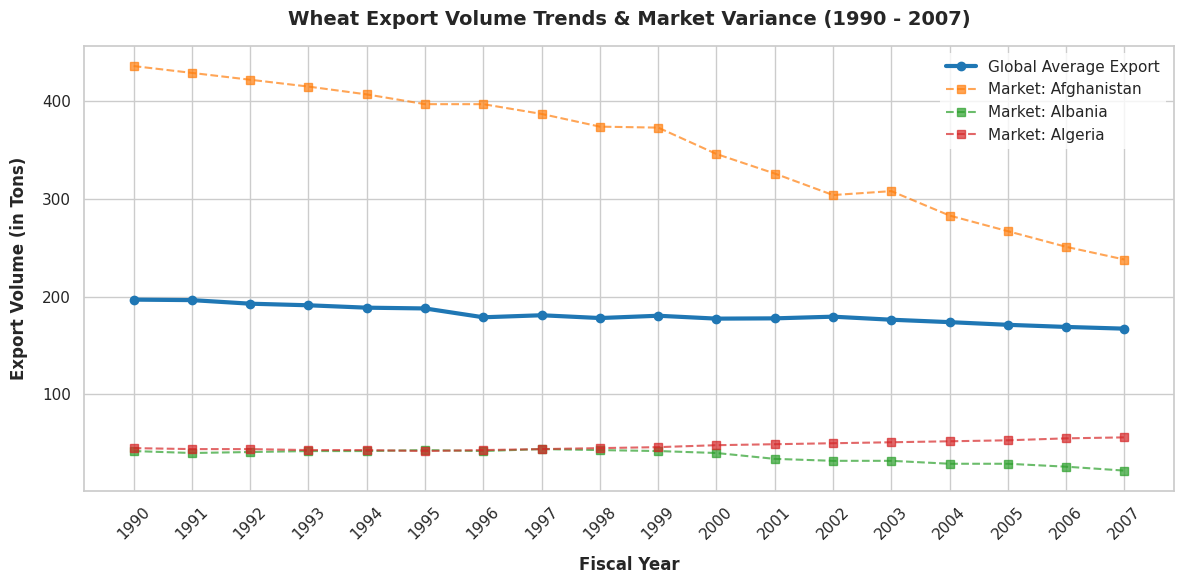

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean aesthetic style for a portfolio
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# 1. Calculate and plot the global average across all countries for each year
years = [col for col in df.columns if col != 'Country']
global_mean = df[years].mean()

plt.plot(years, global_mean, marker='o', linewidth=3, color='#1f77b4', label='Global Average Export')

# 2. Plot a few sample countries to see individual variations (e.g., Afghanistan, Albania, Algeria)
sample_countries = ['Afghanistan', 'Albania', 'Algeria']
colors = ['#ff7f0e', '#2ca02c', '#d62728']

for country, color in zip(sample_countries, colors):
    country_data = df[df['Country'] == country][years].values.flatten()
    plt.plot(years, country_data, linestyle='--', marker='s', alpha=0.7, color=color, label=f'Market: {country}')

# Formatting the chart for high readability
plt.title('Wheat Export Volume Trends & Market Variance (1990 - 2007)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Fiscal Year', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('Export Volume (in Tons)', fontsize=12, fontweight='bold', labelpad=10)
plt.xticks(rotation=45)
plt.legend(frameon=True, facecolor='white', edgecolor='none', fontsize=11)
plt.tight_layout()

# Save image for professional reference and render
plt.savefig('export_trends_eda.png', dpi=300)

In [ ]:
## 5. Feature Engineering: Scaling & Dimensionality Reduction

# 5.1 Standardizing the Features
#Because clustering and dimensional projection rely heavily on geometric distances, variables with higher absolute values can disproportionately influence the model. We apply standard normalization (z-score scaling) to give all historical years equal structural weight.

In [ ]:
from sklearn.preprocessing import StandardScaler

# 1. Separate the text identifier ('Country') from the numerical features (the years)
X = df.drop(columns=['Country'])

# 2. Initialize and apply the StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert back to a DataFrame just to inspect the transformation
df_scaled = pd.DataFrame(X_scaled, columns=X.columns)
df_scaled.head()

,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007
0,1.031105,1.016419,1.021968,1.019423,1.009478,0.986291,1.128200,1.074120,1.039774,0.989390,0.846811,0.724331,0.607753,0.627344,0.519470,0.454736,0.389369,0.334118
1,-0.668467,-0.683941,-0.676939,-0.679417,-0.678571,-0.683806,-0.708152,-0.714132,-0.717253,-0.711612,-0.691216,-0.702798,-0.720209,-0.688420,-0.690181,-0.674791,-0.679274,-0.686033
2,-0.655527,-0.666456,-0.663562,-0.674863,-0.673946,-0.688524,-0.702979,-0.714132,-0.706637,-0.691056,-0.651006,-0.629486,-0.632329,-0.597842,-0.580645,-0.560889,-0.541538,-0.525454
3,-0.668467,-0.797590,-0.841925,-0.788726,-0.794190,-0.782879,-0.925410,-0.813190,-0.881809,-0.886337,-0.852056,-0.839646,-0.852029,-0.812369,-0.785429,-0.760217,-0.760016,-0.766323
4,-0.681408,-0.697054,-0.703693,-0.720408,-0.724819,-0.745137,-0.780571,-0.823617,-0.818110,-0.814392,-0.791741,-0.771222,-0.773914,-0.755162,-0.737805,-0.726996,-0.722020,-0.700202


In [ ]:
### 5.2 Applying Principal Component Analysis (PCA)
#To build a sustainable, repeatable model that handles expanding temporal variables without succumbing to the 'Curse of Dimensionality', we compute the principal components and analyze the cumulative explained variance.

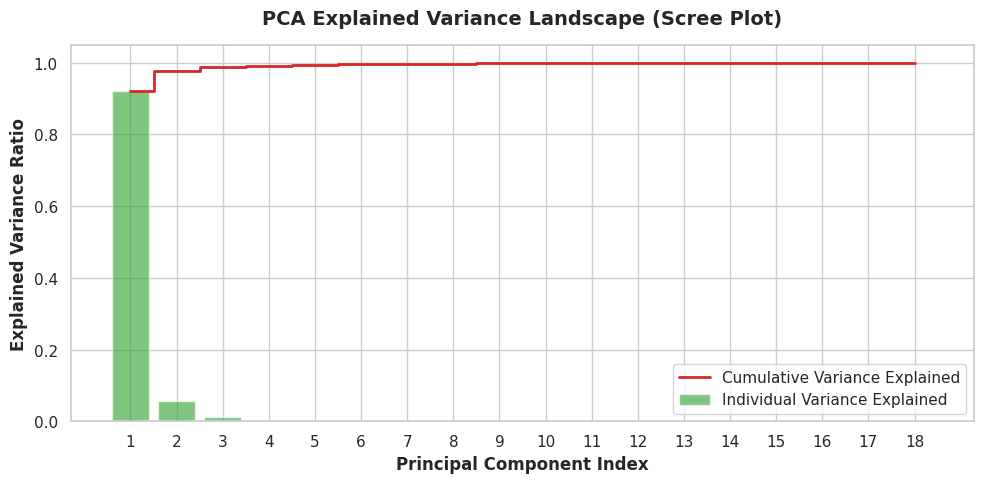

PC1 captures 92.04% of the total historical variance cumulatively.
PC2 captures 97.74% of the total historical variance cumulatively.
PC3 captures 98.91% of the total historical variance cumulatively.


In [ ]:
from sklearn.decomposition import PCA

# 1. Initialize PCA without restricting components initially to see the whole landscape
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# 2. Calculate Cumulative Explained Variance Ratio
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

# 3. Plot the Scree Plot / Cumulative Variance Chart
plt.figure(figsize=(10, 5))
plt.bar(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_, alpha=0.6, align='center', label='Individual Variance Explained', color='#2ca02c')
plt.step(range(1, len(cumulative_variance) + 1), cumulative_variance, where='mid', label='Cumulative Variance Explained', color='#d62728', linewidth=2)

plt.ylabel('Explained Variance Ratio', fontsize=12, fontweight='bold')
plt.xlabel('Principal Component Index', fontsize=12, fontweight='bold')
plt.title('PCA Explained Variance Landscape (Scree Plot)', fontsize=14, fontweight='bold', pad=15)
plt.xticks(range(1, 19))
plt.legend(loc='best', frameon=True, facecolor='white')
plt.tight_layout()
plt.show()

# Print out exactly how much info the first few components capture
for i, variance in enumerate(cumulative_variance[:3]):
    print(f"PC{i+1} captures {variance*100:.2f}% of the total historical variance cumulatively.")

In [ ]:
# 6. Model Optimization: Determining Optimal Cluster Count

# 6.1 The Elbow Method (WCSS Analysis)
# To segment our target markets without arbitrary guessing, we use the Elbow Method. By plotting the Within-Cluster Sum of Squares (WCSS/Inertia) against a range of potential cluster sizes, we pinpoint the mathematical inflection point where adding complexity yields diminishing returns in cluster tightness.

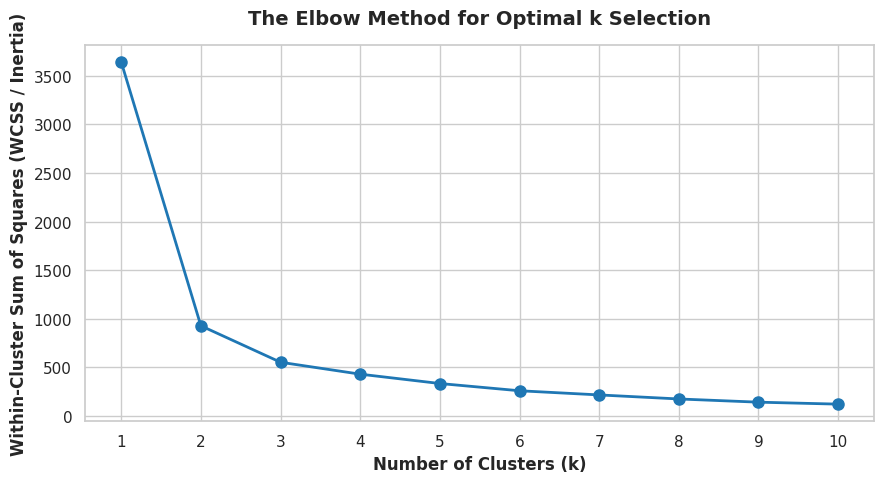

In [ ]:
from sklearn.cluster import KMeans

# 1. We will use the first 2 Principal Components since they explain ~97.74% of variance
X_projected = X_pca[:, :2]

# 2. Compute WCSS for k values from 1 to 10
wcss = []
k_range = range(1, 11)

for k in k_range:
    # Using random_state=42 ensures reproducibility across runs
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_projected)
    wcss.append(kmeans.inertia_)

# 3. Plot the Elbow Chart
plt.figure(figsize=(9, 5))
plt.plot(k_range, wcss, marker='o', linestyle='-', color='#1f77b4', linewidth=2, markersize=8)
plt.title('The Elbow Method for Optimal k Selection', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Number of Clusters (k)', fontsize=12, fontweight='bold')
plt.ylabel('Within-Cluster Sum of Squares (WCSS / Inertia)', fontsize=12, fontweight='bold')
plt.xticks(k_range)
plt.tight_layout()
plt.show()

In [ ]:
## 7. Model Execution & Market Segmentation

# Executing K-Means Clustering ($k=3$)
# With our dimensionality optimized via PCA and our cluster count mathematically validated via WCSS, we execute our final K-Means segmentation model. We map these clusters back to the original countries to build our core business profiles.

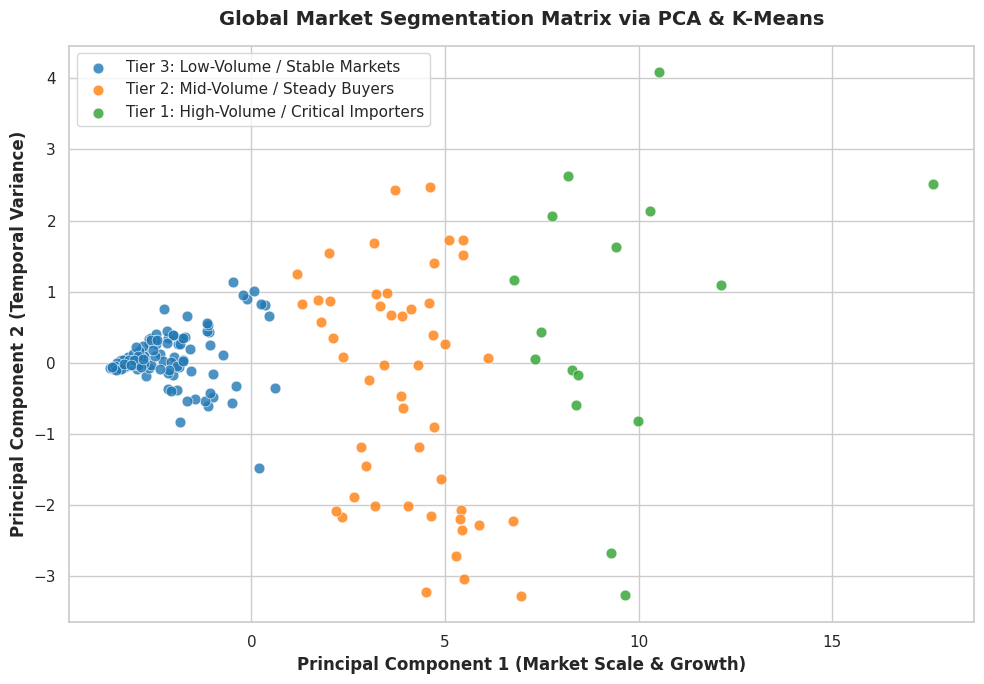

In [ ]:
# 1. Initialize and fit the final K-Means model
final_kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42, n_init=10)
cluster_labels = final_kmeans.fit_predict(X_projected)

# 2. Append the cluster assignments back to our main DataFrame
df['Cluster'] = cluster_labels

# 3. Create a professional scatter plot of our segments in the PCA space
plt.figure(figsize=(10, 7))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
cluster_names = {
    0: "Tier 3: Low-Volume / Stable Markets",
    1: "Tier 2: Mid-Volume / Steady Buyers",
    2: "Tier 1: High-Volume / Critical Importers"
}

for cluster_id in range(3):
    points = X_projected[cluster_labels == cluster_id]
    plt.scatter(points[:, 0], points[:, 1], s=60, color=colors[cluster_id],
                label=cluster_names[cluster_id], alpha=0.8, edgecolors='w', linewidth=0.5)

# Formatting the visual
plt.title('Global Market Segmentation Matrix via PCA & K-Means', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Principal Component 1 (Market Scale & Growth)', fontsize=12, fontweight='bold')
plt.ylabel('Principal Component 2 (Temporal Variance)', fontsize=12, fontweight='bold')
plt.legend(loc='best', frameon=True, facecolor='white', fontsize=11)
plt.tight_layout()
plt.savefig('market_segments_pca.png', dpi=300)
plt.show()

In [ ]:
# 7.2 Strategic Cluster Profiling
# To provide actionable business value, we extract the average export metric for each cluster and view a subset of the countries residing within each tier.

In [ ]:
# View the size and descriptive profile of each cluster based on recent records (e.g., year 2007)
for cluster_id in range(3):
    cluster_df = df[df['Cluster'] == cluster_id]
    print(f"\n{'='*50}")
    print(f"PROFILE: {cluster_names[cluster_id]}")
    print(f"Total Countries in Tier: {len(cluster_df)}")
    print(f"Average Export Volume (2007): {cluster_df['2007'].mean():.2f} tons")
    print(f"Sample Markets: {', '.join(cluster_df['Country'].head(5).tolist())}")


PROFILE: Tier 3: Low-Volume / Stable Markets
Total Countries in Tier: 141
Average Export Volume (2007): 45.36 tons
Sample Markets: Albania, Algeria, American Samoa, Andorra, Anguilla

PROFILE: Tier 2: Mid-Volume / Steady Buyers
Total Countries in Tier: 50
Average Export Volume (2007): 373.88 tons
Sample Markets: Afghanistan, Angola, Bolivia, Botswana, Burkina Faso

PROFILE: Tier 1: High-Volume / Critical Importers
Total Countries in Tier: 16
Average Export Volume (2007): 595.75 tons
Sample Markets: Bangladesh, Bhutan, Cambodia, Korea, Dem. Rep., Djibouti


In [ ]:
# ## 8. Strategic Executive Summary & Visual Insights

# 8.1 Mapping Clusters Back to Historical Trends
# To deliver direct, non-technical value to stakeholders, we map the abstract clusters back onto the original temporal timeline. This allows us to track the collective trajectory of each market tier from 1990 to 2007.

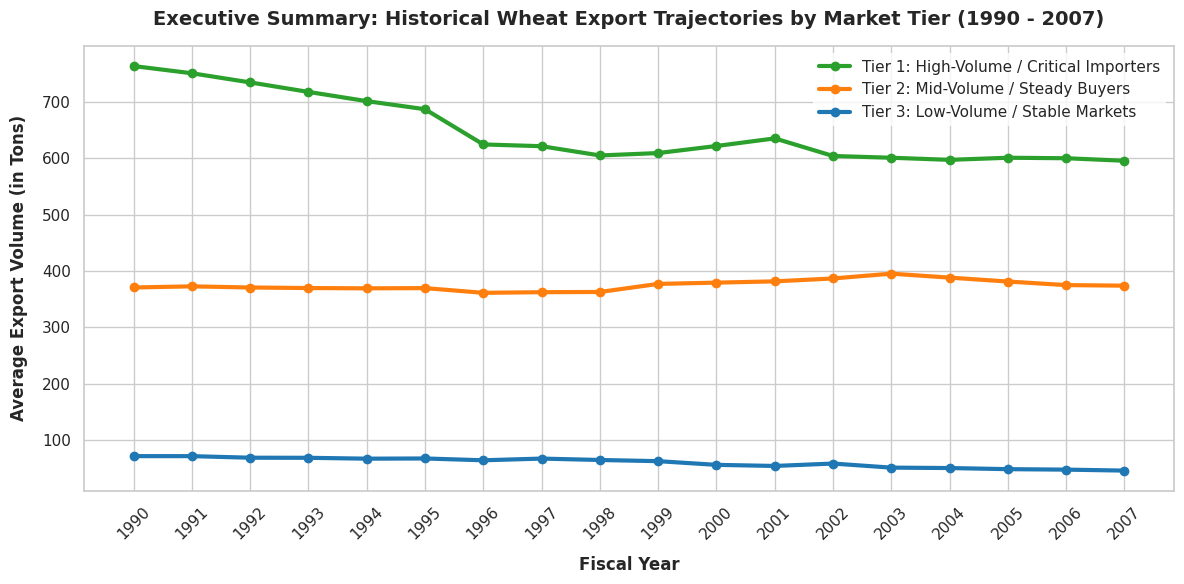

In [ ]:
# 1. Define high-value descriptive names for our clusters
cluster_names = {
    0: "Tier 3: Low-Volume / Stable Markets",
    1: "Tier 2: Mid-Volume / Steady Buyers",
    2: "Tier 1: High-Volume / Critical Importers"
}
df['Cluster_Name'] = df['Cluster'].map(cluster_names)

# 2. Group the raw data by our clusters and compute the mean across all years
years = [col for col in df.columns if col not in ['Country', 'Cluster', 'Cluster_Name']]
cluster_trends = df.groupby('Cluster_Name')[years].mean()

# 3. Plot the final timeline
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# Map specific professional colors to match our previous presentation layers
colors = {
    "Tier 1: High-Volume / Critical Importers": '#2ca02c', # Green
    "Tier 2: Mid-Volume / Steady Buyers": '#ff7f0e',      # Orange
    "Tier 3: Low-Volume / Stable Markets": '#1f77b4'       # Blue
}

for cluster_type in [
    "Tier 1: High-Volume / Critical Importers",
    "Tier 2: Mid-Volume / Steady Buyers",
    "Tier 3: Low-Volume / Stable Markets"
]:
    plt.plot(years, cluster_trends.loc[cluster_type], marker='o', linewidth=3,
             color=colors[cluster_type], label=cluster_type)

# Polish the chart aesthetics for a professional report
plt.title('Executive Summary: Historical Wheat Export Trajectories by Market Tier (1990 - 2007)',
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Fiscal Year', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('Average Export Volume (in Tons)', fontsize=12, fontweight='bold', labelpad=10)
plt.xticks(rotation=45)
plt.legend(frameon=True, facecolor='white', edgecolor='none', fontsize=11, loc='upper right')
plt.tight_layout()

# Save the final masterpiece
plt.savefig('executive_cluster_trends.png', dpi=300)
plt.show()